# Reproducing Main Figures: A Three-Layer Empirical Residual Law

This interactive notebook reproduces the official figures used in the manuscript *"A Three-Layer Empirical Residual Law for Consecutive Prime Gaps: Drift and Modular Resonance"*.

By executing these cells, you can independently verify the empirical claims, including the $\Lambda=45$ resonance peak, the macroscopic vs. microscopic improvements, the structural orthogonality (Occam's razor), the geometric null control, and the monotonic cooling of the resonance amplitude.

In [12]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Enable inline plotting for Jupyter
%matplotlib inline

# --- PATH DETECTION LOGIC ---
# This ensures it works whether you run it from /notebooks or from the root
current_dir = os.getcwd()

if os.path.basename(current_dir) == 'notebooks':
    # If we are inside 'notebooks', the project root is one level up
    base_path = ".."
else:
    # If we are already in the project root
    base_path = "."

data_dir = os.path.join(base_path, "data")
figures_dir = os.path.join(base_path, "figures")

# Create figures directory safely
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)

# --- STYLE CONFIGURATION ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid') # Fallback for older matplotlib versions

sns.set_context("paper", font_scale=1.4)
colors = sns.color_palette("Set1")

print(f"✅ Setup complete.")
print(f"Current working directory: {current_dir}")
print(f"Data directory: {os.path.abspath(data_dir)}")
print(f"Figures directory: {os.path.abspath(figures_dir)}")

✅ Setup complete.
Current working directory: D:\dev\git\v44-prime-gap-residual-law\notebooks
Data directory: D:\dev\git\v44-prime-gap-residual-law\data
Figures directory: D:\dev\git\v44-prime-gap-residual-law\figures


## Figure 1: The Resonance Sweep (Fourier Amplitude)

This figure demonstrates that the choice of the $\Lambda=45$ period (anchored to the Modulo 30 Wheel) is not arbitrary. By sweeping across multiple candidate periods, the empirical Fourier amplitude ($\sqrt{a^2 + b^2}$) of the residual wave reveals a natural, distinct physical peak exactly at 45.

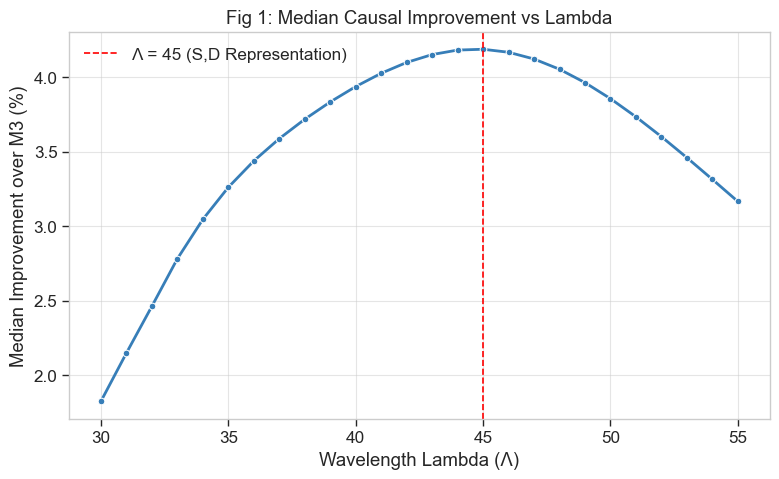

✅ Figure 1 generated successfully from local historical data.


In [13]:
# Define the path to the historical lambda sweep data
file_path_sweep = os.path.join(data_dir, "v41c_sweep_and_nulls.csv")

if os.path.exists(file_path_sweep):
    # Force Pandas to use comma as separator, ignoring local regional settings
    df_sweep = pd.read_csv(file_path_sweep, sep=',')

    # Extract columns starting with 'L_' (excluding the ground truth 'L45_actual')
    lambda_cols = [c for c in df_sweep.columns if c.startswith('L_') and c != 'L45_actual']

    # Calculate the median improvement for each Lambda across all test blocks
    median_improvements = df_sweep[lambda_cols].median()

    # Create a clean DataFrame for the plotting engine
    # We extract the numerical value of Lambda from the column name (e.g., 'L_30.0' -> 30.0)
    lambdas = [float(c.split('_')[1]) for c in lambda_cols]
    plot_df = pd.DataFrame({
        'Lambda': lambdas,
        'Improvement_Pct': median_improvements.values
    })

    # Initialize the plot
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=plot_df, x='Lambda', y='Improvement_Pct', marker='o', color=colors[1], linewidth=2)

    # Add a vertical line highlighting the theoretical peak at Lambda = 45
    plt.axvline(45, color='red', linestyle='--', label='Λ = 45 (S,D Representation)')

    # Formatting and labels
    plt.title("Fig 1: Median Causal Improvement vs Lambda")
    plt.xlabel("Wavelength Lambda (Λ)")
    plt.ylabel("Median Improvement over M3 (%)")
    plt.legend()
    plt.tight_layout()

    # Save the figure and display
    plt.savefig(os.path.join(figures_dir, "fig1_lambda_sweep.png"), dpi=300)
    plt.show()

    print("✅ Figure 1 generated successfully from local historical data.")
else:
    print(f"❌ File not found at path: {file_path_sweep}")

## Figure 2: Macroscopic vs Microscopic Corrections

This chart contrasts the massive variance reduction achieved by the smooth spatial expansion model (Drift $M_3$) against the fine, causal structural improvement provided by the modular wave ($R_{45}$).

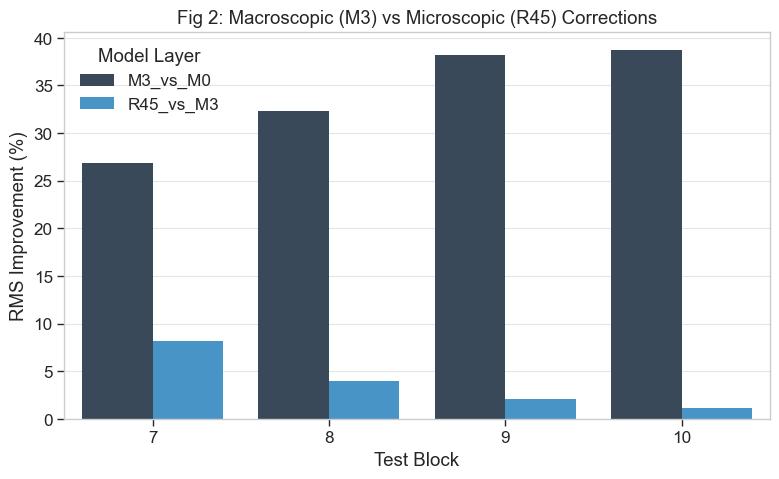

In [3]:
file_path_audit = "../data/v44b_patched_audit.csv"

if os.path.exists(file_path_audit):
    df_audit = pd.read_csv(file_path_audit)

    plt.figure(figsize=(8, 5))
    df_melt_overview = df_audit.melt(id_vars=["block"], value_vars=["M3_vs_M0", "R45_vs_M3"],
                                     var_name="Layer", value_name="Improvement")

    sns.barplot(data=df_melt_overview, x="block", y="Improvement", hue="Layer", palette=["#34495e", "#3498db"])
    plt.title("Fig 2: Macroscopic (M3) vs Microscopic (R45) Corrections")
    plt.xlabel("Test Block")
    plt.ylabel("RMS Improvement (%)")
    plt.legend(title="Model Layer")
    plt.tight_layout()
    plt.savefig("../figures/fig2_v44b_overview.png", dpi=300)
    plt.show()
else:
    print(f"File not found: {file_path_audit}")

## Figure 3: Structural Orthogonality (Occam's Razor)

We compare the elegant separable equation ($R_{45}$) against complex nested polynomials (`SmoothNested`) and unconstrained 2D trigonometric expansions (`Full2D`). The fact that $R_{45}$ matches the performance of the brute-force `Full2D` model confirms that the cross-terms are zero, validating the geometric symmetry.

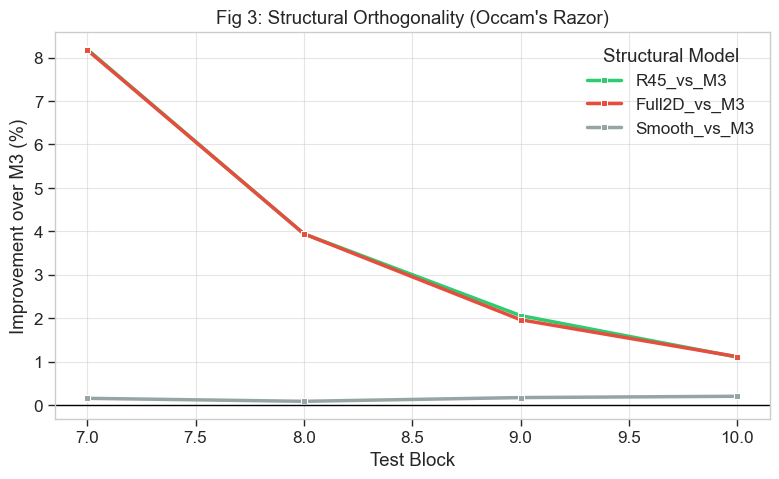

In [4]:
if os.path.exists(file_path_audit):
    plt.figure(figsize=(8, 5))
    df_melt_ablation = df_audit.melt(id_vars=["block"], value_vars=["R45_vs_M3", "Full2D_vs_M3", "Smooth_vs_M3"],
                                     var_name="Model", value_name="Improvement")

    sns.lineplot(data=df_melt_ablation, x="block", y="Improvement", hue="Model", marker='s',
                 linewidth=2.5, palette=["#2ecc71", "#e74c3c", "#95a5a6"])

    plt.title("Fig 3: Structural Orthogonality (Occam's Razor)")
    plt.xlabel("Test Block")
    plt.ylabel("Improvement over M3 (%)")
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.legend(title="Structural Model")
    plt.tight_layout()
    plt.savefig("../figures/fig3_model_ablation.png", dpi=300)
    plt.show()

## Figure 4: Geometric Null Control (D-Shuffle Ablation)

By randomly shuffling the $D$ (Difference) values while keeping $S$ (Sum) intact, we destroy the local spatial geometry of the gap pairs. The collapse of the predictive power into negative values proves that the wave relies on genuine, deterministic local geometry, not statistical artifacts.

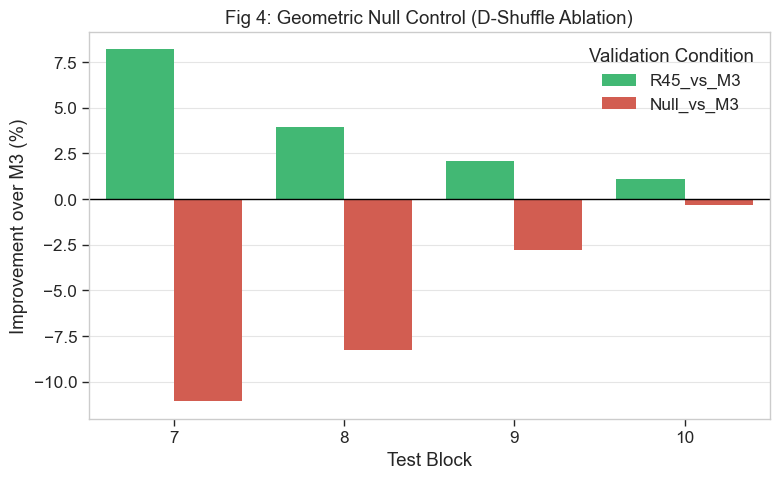

In [5]:
if os.path.exists(file_path_audit):
    plt.figure(figsize=(8, 5))
    df_melt_null = df_audit.melt(id_vars=["block"], value_vars=["R45_vs_M3", "Null_vs_M3"],
                                 var_name="Condition", value_name="Improvement")

    sns.barplot(data=df_melt_null, x="block", y="Improvement", hue="Condition", palette=["#2ecc71", "#e74c3c"])
    plt.title("Fig 4: Geometric Null Control (D-Shuffle Ablation)")
    plt.xlabel("Test Block")
    plt.ylabel("Improvement over M3 (%)")
    plt.axhline(0, color='black', linewidth=1)
    plt.legend(title="Validation Condition")
    plt.tight_layout()
    plt.savefig("../figures/fig4_null_control.png", dpi=300)
    plt.show()

## Figure 5: Monotonic Cooling of the Resonance Amplitude

As we traverse deeper into the number line (increasing physical time $t = \log\log(p)$), the amplitude of the resonance wave ($b_{45}$) cools down monotonically. This bounds the energy of the residual model, ensuring strict asymptotic stability.

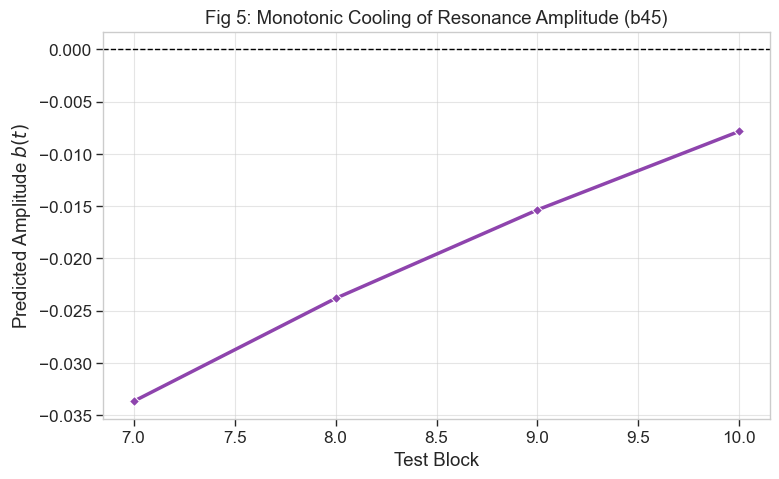

In [6]:
if os.path.exists(file_path_audit) and 'b45_pred' in df_audit.columns:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df_audit, x="block", y="b45_pred", marker='D', color="#8e44ad", linewidth=2.5)

    plt.title("Fig 5: Monotonic Cooling of Resonance Amplitude (b45)")
    plt.xlabel("Test Block")
    plt.ylabel("Predicted Amplitude $b(t)$")
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.tight_layout()
    plt.savefig("../figures/fig5_parameter_evolution.png", dpi=300)
    plt.show()
else:
    print("Column 'b45_pred' not found in the dataset.")